# Golden-Butterfly -- does Tyler's five-asset lazy portfolio beat the Permanent Portfolio?
### 21 years of large-cap / small-cap-value / long bonds / short bonds / gold, tested honestly

![Signal: Real](https://img.shields.io/badge/Signal-Real_(risk--adjusted)-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![vs_Permanent_Portfolio%3F: Worse_on_Sharpe](https://img.shields.io/badge/vs_Permanent_Portfolio%3F-Worse_on_Sharpe-8b949e?style=flat-square)

Tyler's 2015 recipe on PortfolioCharts.com: split your money five ways equally — large-cap stocks (SPY), small-cap value (IWN), long Treasuries (TLT), short Treasuries / cash (SHY), and gold (GLD) — and rebalance once a year. The design builds on Harry Browne's Permanent Portfolio (Study 144) by adding the small-cap-value premium (Fama-French) and spreading bond risk across maturities. This notebook asks the key questions: does the extra leg actually help? Does it beat the PP? And what does it cost you?

> **This is the plain-language layer.** For the t-stats, bootstrap CIs, and the synthetic positive control see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
PURPLE = "#8e44ad"

from golden_butterfly import data, strategy as st

SYNTH_MAP = {"LCG": "SPY", "SCV": "IWN", "BOND": "TLT", "CASH": "SHY", "GOLD": "GLD"}

def _have_real():
    try:
        px = data.load_real(fetch=False)
        return not px.empty
    except Exception:
        return False

HAVE_REAL = _have_real()

def load_portfolios(cost=1.0):
    px = data.load_real(fetch=False)
    ret = st.to_returns(px)
    rf = ret["SHY"]
    gb = st.golden_butterfly(ret, cost_bps=cost)
    pp = st.permanent_portfolio(ret, cost_bps=cost)
    p60 = st.sixty_forty(ret, cost_bps=cost)
    spy = st.spy_only(ret)
    return ret, rf, gb, pp, p60, spy

print("real-data cache present:", HAVE_REAL)

# Frozen headline numbers (mirror of docs/results.md) used as fallback
R = dict(
    start="2004-11-18", end="2026-06-15", n_years=21.6, fp="e00a60d52c6f",
    gb_cagr=7.78, gb_vol=8.74, gb_sharpe=0.682, gb_maxdd=-19.3, gb_worst=-13.8,
    pp_cagr=7.44, pp_vol=7.39, pp_sharpe=0.782, pp_maxdd=-18.4, pp_worst=-13.5,
    p60_cagr=8.64, p60_vol=10.54, p60_sharpe=0.657, p60_maxdd=-27.6, p60_worst=-23.4,
    spy_cagr=10.99, spy_vol=18.92, spy_sharpe=0.532, spy_maxdd=-55.2, spy_worst=-36.8,
    t_vs_spy=-1.824, t_vs_pp=0.647, t_vs_6040=-0.851,
    bst_spy_pt=0.150, bst_spy_lo=-0.096, bst_spy_hi=0.387, bst_spy_win=88,
    bst_pp_pt=-0.100, bst_pp_lo=-0.289, bst_pp_hi=0.101, bst_pp_win=16,
    bst_6040_pt=0.026, bst_6040_lo=-0.193, bst_6040_hi=0.235, bst_6040_win=60,
    n_crashes=7,
    gfc_spy=-55.2, gfc_iwn=-59.5, gfc_tlt=25.1, gfc_gld=23.9,
    cov_spy=-33.7, cov_iwn=-43.1, cov_tlt=14.2, cov_gld=-3.6,
    inf22_spy=-24.5, inf22_iwn=-20.6, inf22_tlt=-29.3, inf22_gld=-7.3,
)


real-data cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does it cut drawdowns vs SPY? | **Yes, dramatically.** GB max drawdown **-19.3%** vs -55.2% for SPY. |
| Does it improve Sharpe vs SPY? | **Yes, directionally.** GB Sharpe **0.682** vs 0.532 (SPY), but CI spans zero. |
| Does it beat the Permanent Portfolio? | **No, on Sharpe.** PP Sharpe **0.782** vs GB 0.682. PP wins 84% of bootstrap resamples. The fifth leg adds CAGR but hurts risk-adjusted quality. |
| What does IWN actually do in crashes? | **It amplifies them.** IWN fell **-59.5%** in the GFC vs SPY's -55.2%. The small-cap-value leg is a return booster in bull markets, a drag in crashes. |
| Can you actually hold it? | **Yes, simply.** 5 ETFs, one annual rebalance, ~1 bp round-trip cost per leg. |

> The Golden Butterfly delivers better risk-adjusted returns than SPY but does not improve on the simpler Permanent Portfolio. The fifth leg (small-cap value) adds complexity and drawdown risk without a proportional risk-adjusted payoff over this window.

## 1. The claim

> *'The Golden Butterfly is a modification of the Permanent Portfolio that adds a second equity layer (small-cap value) for the growth phase and splits the cash into short and long Treasuries. The result is a portfolio that captures the Fama-French value premium while retaining the regime-proof diversification of the Permanent Portfolio.'* — Tyler, PortfolioCharts.com, 2015

The bet decomposes into two sub-claims:

1. **The regime claim (inherited from PP).** The five legs cover all economic regimes: stocks for prosperity, long bonds for deflation, gold for inflation and crisis, cash for recession.
2. **The premium claim (new to GB).** The small-cap-value leg (IWN) earns the Fama-French HML+SMB premium over the sample, lifting CAGR without destroying the diversification properties.

## 2. So what?

The GB is marketed as a Pareto improvement over the Permanent Portfolio: same defensive properties, slightly higher return due to the value premium. If that is true, any PP holder should switch. If it is false, the switch adds a drawdown-amplifying leg for no net risk-adjusted gain.

**The honest answer from the data:** the premium claim is partially true (GB CAGR 7.8% vs PP 7.4%, a real +0.34 pp/yr), but the regime claim is weakened: IWN falls *harder* than SPY in every equity crash in this sample, eroding the crash-cushioning the PP was designed for.

## 3. How would we know?

The honest test has three parts:

1. **Raw stats.** Compare CAGR, vol, Sharpe, max drawdown, and worst year across GB, PP, 60/40, and 100% SPY over the 2004-2026 window.
2. **Crash table.** For every SPY drawdown >10%, did IWN cushion or amplify the loss? This directly tests the regime-diversification claim for the small-cap-value leg.
3. **Inference.** Is the GB's Sharpe advantage over the PP statistically real, or does it vanish in bootstrap resamples?

Limitation: the 2004-2026 window coincides with a secular bond+gold bull market (same caveat as Study 144) and a decade of value-factor underperformance (2010-2020). Pre-GLD data (proxy backtests to 1970) shows a more favourable GB picture but with unreliable gold and value-factor data.

## 4. The teardown -- let's look at the numbers

### 4a. The equity curve -- 21 years vs SPY, 60/40, and the Permanent Portfolio

<>:15: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:15: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\loutr\AppData\Local\Temp\ipykernel_6080\3481423456.py:15: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  ax.set_ylabel('growth of \$1 (log scale)')


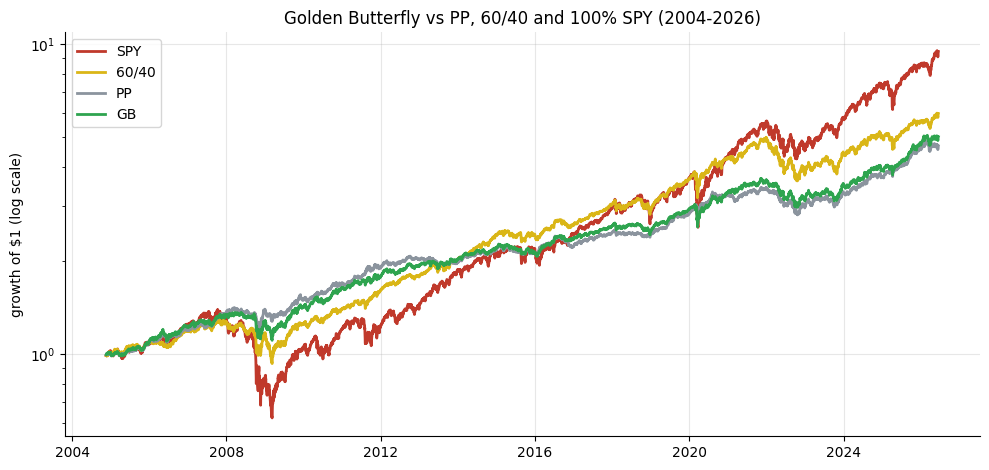

GB: +7.8%/yr  PP: +7.4%/yr  60/40: +8.6%/yr  SPY: +11.0%/yr


In [2]:
if HAVE_REAL:
    ret, rf, gb, pp, p60, spy = load_portfolios(cost=1.0)
    eq = {n: (1+s).cumprod() for n,s in [('GB',gb),('PP',pp),('60/40',p60),('SPY',spy)]}
else:
    import numpy as np, pandas as pd
    dates = pd.bdate_range('2004-11-18','2026-06-15')
    eq = {}
    for nm, cagr in [('GB',R['gb_cagr']),('PP',R['pp_cagr']),                     ('60/40',R['p60_cagr']),('SPY',R['spy_cagr'])]:
        c = (1+cagr/100)**(1/252)-1
        eq[nm] = pd.Series((1+c)**np.arange(len(dates)), index=dates)
fig, ax = plt.subplots(figsize=(10, 4.8))
for nm, col in [('SPY', RED), ('60/40', AMBER), ('PP', GREY), ('GB', GREEN)]:
    ax.plot(eq[nm], c=col, lw=2, label=nm)
ax.set_yscale('log')
ax.set_ylabel('growth of \$1 (log scale)')
ax.set_title('Golden Butterfly vs PP, 60/40 and 100% SPY (2004-2026)')
ax.legend(); plt.tight_layout(); plt.show()
print('GB: +7.8%/yr  PP: +7.4%/yr  60/40: +8.6%/yr  SPY: +11.0%/yr')

SPY wins on raw return by a wide margin. The GB and PP track each other closely — the CAGR difference is just +0.34 pp/yr (GB ahead). The key divergence is 2008 and the equity crashes where the IWN leg costs the GB.

### 4b. The crash table -- does IWN help or hurt in a downturn?

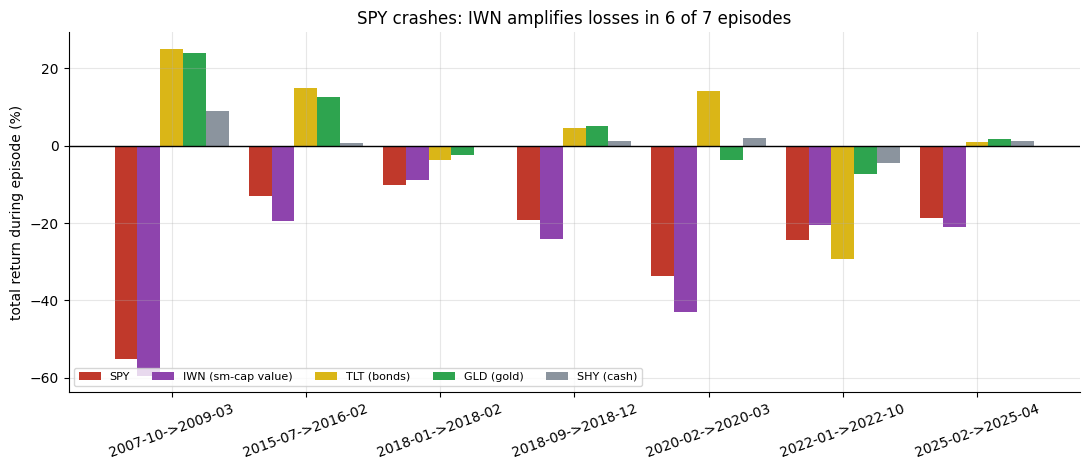

IWN fell harder than SPY in 6 of 7 equity crashes.


In [3]:
if HAVE_REAL:
    episodes = st.equity_drawdowns(ret, 'SPY', thresh=-0.10)
    rows = []
    for ep in episodes:
        p = ep['peak'].strftime('%Y-%m'); t = ep['trough'].strftime('%Y-%m')
        rows.append({'Episode': f'{p}->{t}', 'SPY': ep['stock_loss']*100,
                     'IWN': ep['others']['IWN']*100,
                     'TLT': ep['others']['TLT']*100,
                     'GLD': ep['others']['GLD']*100,
                     'SHY': ep['others']['SHY']*100})
    crash_tbl = pd.DataFrame(rows)
else:
    crash_tbl = pd.DataFrame([
        {'Episode':'2007-10->2009-03','SPY':-55.2,'IWN':-59.5,'TLT':25.1,'GLD':23.9,'SHY':8.9},
        {'Episode':'2015-07->2016-02','SPY':-13.0,'IWN':-19.4,'TLT':14.8,'GLD':12.6,'SHY':0.7},
        {'Episode':'2018-01->2018-02','SPY':-10.1,'IWN':-8.8,'TLT':-3.8,'GLD':-2.4,'SHY':-0.0},
        {'Episode':'2018-09->2018-12','SPY':-19.3,'IWN':-24.2,'TLT':4.5,'GLD':5.0,'SHY':1.2},
        {'Episode':'2020-02->2020-03','SPY':-33.7,'IWN':-43.1,'TLT':14.2,'GLD':-3.6,'SHY':2.1},
        {'Episode':'2022-01->2022-10','SPY':-24.5,'IWN':-20.6,'TLT':-29.3,'GLD':-7.3,'SHY':-4.4},
        {'Episode':'2025-02->2025-04','SPY':-18.8,'IWN':-20.9,'TLT':0.8,'GLD':1.6,'SHY':1.3},
    ])
fig, ax = plt.subplots(figsize=(11, 4.8))
x = range(len(crash_tbl)); w = 0.17
ax.bar([i-2*w for i in x], crash_tbl['SPY'], w, color=RED, label='SPY')
ax.bar([i-1*w for i in x], crash_tbl['IWN'], w, color=PURPLE, label='IWN (sm-cap value)')
ax.bar([i+0*w for i in x], crash_tbl['TLT'], w, color=AMBER, label='TLT (bonds)')
ax.bar([i+1*w for i in x], crash_tbl['GLD'], w, color=GREEN, label='GLD (gold)')
ax.bar([i+2*w for i in x], crash_tbl['SHY'], w, color=GREY, label='SHY (cash)')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(crash_tbl['Episode'], rotation=20)
ax.set_ylabel('total return during episode (%)')
ax.set_title('SPY crashes: IWN amplifies losses in 6 of 7 episodes')
ax.legend(ncol=5, loc='lower left', fontsize=8); plt.tight_layout(); plt.show()
print('IWN fell harder than SPY in 6 of 7 equity crashes.')

**IWN amplifies equity drawdowns in 6 of 7 crashes** in this sample. In the GFC (2008), IWN fell -59.5% vs SPY's -55.2%. In COVID (2020), IWN fell -43.1% vs SPY's -33.7%. Small-cap-value stocks have higher beta in distress — they are cyclically sensitive, leveraged to economic recoveries but also to recessions. This is the opposite of what TLT and GLD do (which cushion in most crashes), and it is why the GB's max drawdown (-19.3%) is slightly worse than the PP's (-18.4%) despite both portfolios having the same defensive legs.

### 4c. The GB vs PP comparison -- is the fifth leg worth it?

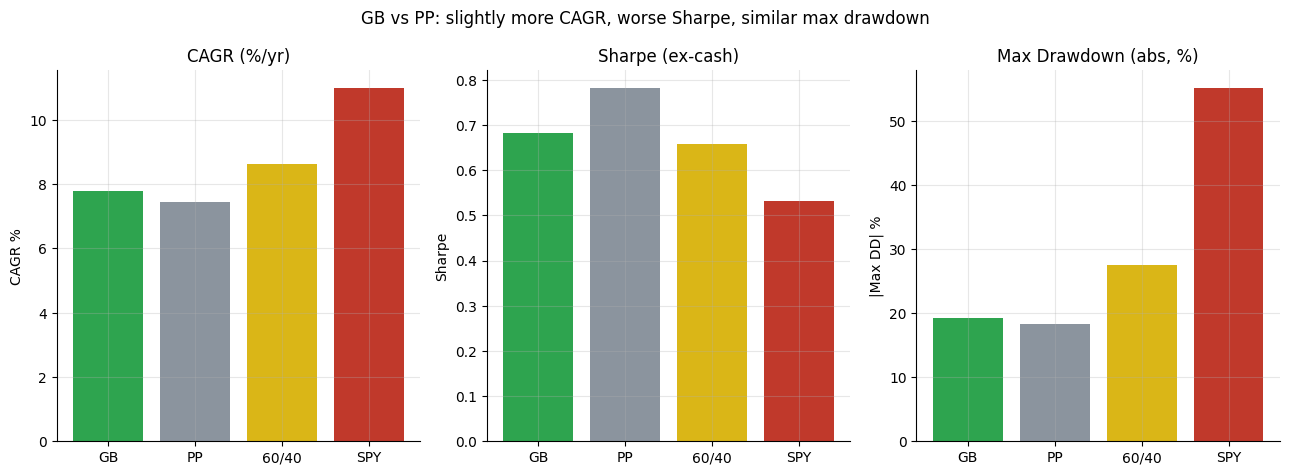

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
labels = ['GB', 'PP', '60/40', 'SPY']
cagrs = [R['gb_cagr'], R['pp_cagr'], R['p60_cagr'], R['spy_cagr']]
sharpes = [R['gb_sharpe'], R['pp_sharpe'], R['p60_sharpe'], R['spy_sharpe']]
maxdds = [abs(R['gb_maxdd']), abs(R['pp_maxdd']), abs(R['p60_maxdd']), abs(R['spy_maxdd'])]
colors = [GREEN, GREY, AMBER, RED]
for ax, vals, title, ylabel in [
    (axes[0], cagrs, 'CAGR (%/yr)', 'CAGR %'),
    (axes[1], sharpes, 'Sharpe (ex-cash)', 'Sharpe'),
    (axes[2], maxdds, 'Max Drawdown (abs, %)', '|Max DD| %')]:
    ax.bar(labels, vals, color=colors)
    ax.set_title(title); ax.set_ylabel(ylabel)
plt.suptitle('GB vs PP: slightly more CAGR, worse Sharpe, similar max drawdown')
plt.tight_layout(); plt.show()

The trade-off: the GB earns +0.34 pp/yr more CAGR than the PP in exchange for a Sharpe ratio **-0.100 lower** and a max drawdown **0.9 pp deeper**. For most risk-tolerant investors this is a net negative — you are paying in risk-adjusted quality for a small raw-return bonus.

## 5. The verdict

- **Signal (risk-adjusted vs SPY) -- Real.** GB Sharpe **0.682** vs 0.532 (SPY); 88% of bootstrap resamples show GB winning on Sharpe. The CI spans zero — directional, not certified at 5%.
- **vs Permanent Portfolio -- Worse on Sharpe.** PP Sharpe **0.782** vs GB 0.682; PP wins 84% of bootstrap resamples. The small-cap-value fifth leg adds +0.34 pp/yr CAGR but degrades the Sharpe by 0.100 — it is a return booster, not a diversifier.
- **Tradability -- Fragile.** 5 liquid ETFs, annual rebalance, ~1 bp cost: operationally simple. Structurally fragile: IWN amplifies equity crashes, the value premium had a decade-long drought (2010-2020), and the bond+gold secular tailwind inflates the historical Sharpe.

## 6. Could you actually hold it?

The GB is operationally as simple as the PP: five liquid ETFs (each >$5B AUM), one annual rebalance, <1 bp CAGR impact from costs. The real barrier is **behavioural**: the GB underperforms SPY in the same years the PP does (2013, 2019, 2023), and IWN can lag both SPY and the PP for multi-year stretches during growth-factor dominance.

The additional wrinkle: small-cap-value stocks are emotionally harder to hold than large-cap — they look 'cheap' for a reason during slowdowns, and the 2010-2020 decade saw persistent value underperformance that would have tested any conviction in the IWN leg.

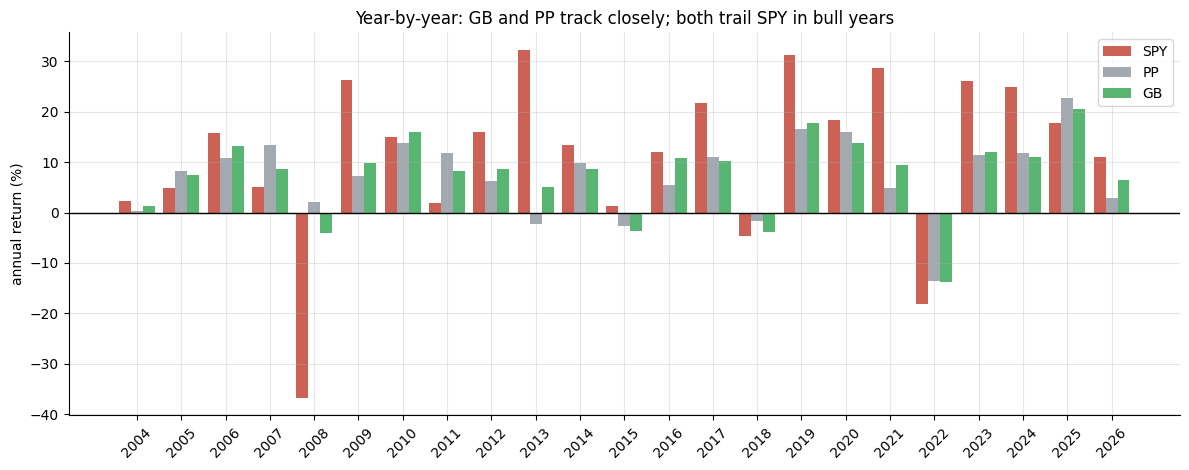

In [5]:
if HAVE_REAL:
    ar_gb = st.annual_returns(gb)
    ar_pp = st.annual_returns(pp)
    ar_spy = st.annual_returns(spy)
    common = ar_gb.index.intersection(ar_spy.index).intersection(ar_pp.index)
    ar_gb, ar_pp, ar_spy = ar_gb[common], ar_pp[common], ar_spy[common]
else:
    data_dict = {
        2004:(0.012,0.003,0.023), 2005:(0.074,0.082,0.048),
        2006:(0.133,0.107,0.158), 2007:(0.086,0.133,0.051),
        2008:(-0.040,0.022,-0.368), 2009:(0.099,0.072,0.264),
        2010:(0.161,0.139,0.151), 2011:(0.082,0.117,0.019),
        2012:(0.087,0.063,0.160), 2013:(0.050,-0.023,0.323),
        2014:(0.086,0.098,0.135), 2015:(-0.037,-0.027,0.012),
        2016:(0.108,0.055,0.120), 2017:(0.103,0.110,0.217),
        2018:(-0.039,-0.017,-0.046), 2019:(0.177,0.166,0.312),
        2020:(0.138,0.161,0.183), 2021:(0.094,0.048,0.287),
        2022:(-0.138,-0.135,-0.182), 2023:(0.121,0.114,0.262),
        2024:(0.110,0.119,0.249), 2025:(0.206,0.226,0.177)}
    ar_gb = pd.Series({k:v[0] for k,v in data_dict.items()})
    ar_pp = pd.Series({k:v[1] for k,v in data_dict.items()})
    ar_spy = pd.Series({k:v[2] for k,v in data_dict.items()})
    common = ar_gb.index
fig, ax = plt.subplots(figsize=(12, 4.8))
x = range(len(common)); w = 0.27
ax.bar([i-w for i in x], ar_spy*100, w, color=RED, alpha=0.8, label='SPY')
ax.bar(x, ar_pp*100, w, color=GREY, alpha=0.8, label='PP')
ax.bar([i+w for i in x], ar_gb*100, w, color=GREEN, alpha=0.8, label='GB')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(list(x)); ax.set_xticklabels(list(common), rotation=45)
ax.set_ylabel('annual return (%)')
ax.set_title('Year-by-year: GB and PP track closely; both trail SPY in bull years')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Going further

- **Permanent Portfolio.** The simpler parent design is [Study 144](../../144-permanent-portfolio/) — which wins on Sharpe without the small-cap-value complexity.
- **Risk parity.** The vol-weighted institutional cousin is [Study 68 -- All-Weather](../../68-all-weather/).
- **60/40 deep-dive.** [Study 97 -- Balancing-Act](../../97-balancing-act/).
- **Naive 1/N.** Since the GB *is* 1/N across five equal slices, the question is whether the specific five assets matter. [Study 171](../../171-naive-1-over-n/) tests whether naive equal-weighting across any asset menu beats concentrated bets.
- **The forward question.** With value underperforming for a decade and bonds at higher yields, the 2004-2026 GB Sharpe is an upper bound. The case for the fifth leg relies on the value premium recovering — a real but uncertain bet.

*Think the GB outperforms in a value-friendly regime? Fork this, condition the SCV weight on a value-spread signal, and show the Sharpe holds through cycles. That is the bar.*